In [1]:
%matplotlib widget
import numpy as np
import glob
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

 # 0  he 2 4685.68A
 # 1  H  1 4861.32A
 # 2  o  3 4958.91A
 # 3  o  3 5006.84A
 # 4  blnd 6300.00A
 # 5  h  1 6562.80A
 # 6  n  2 6583.45A
 # 7  s  2 6716.44A
 # 8  Blnd 6720.00A
 # 9  s  2 6730.82A

In [2]:
out_list = glob.glob('*_out.txt')
out_list
data_dict = {k:d for k, d in 
    zip([tuple([float(i[1:]) for i in j.split('_')[1:3]]) for j in out_list],
        [pd.read_csv(i, skiprows=2, header=None, 
            sep='\t', index_col=False, names=['line', 'flux']) for i in out_list])}

for i in list(data_dict.values()):
    flux = i['flux']
    i.loc[len(i)] = {'line':'n2_ha', 'flux':(flux.iloc[6] / flux.iloc[5])}
    i.loc[len(i)] = {'line':'s2_ha', 'flux':(flux.iloc[7] + flux.iloc[9]) / flux.iloc[5]}
    i.loc[len(i)] = {'line':'o1_ha', 'flux':(flux.iloc[4] / flux.iloc[5])}
    i.loc[len(i)] = {'line':'he2_hb', 'flux':(flux.iloc[0] / flux.iloc[1])}
    i.loc[len(i)] = {'line':'o3_hb', 'flux':(flux.iloc[3] / flux.iloc[1])}
    i.loc[len(i)] = {'line':'ha_hb', 'flux':(flux.iloc[5] / flux.iloc[1])}

In [3]:
# 10, 11, 12, 13, 14

Text(0, 0.5, '$\\log(U)$')

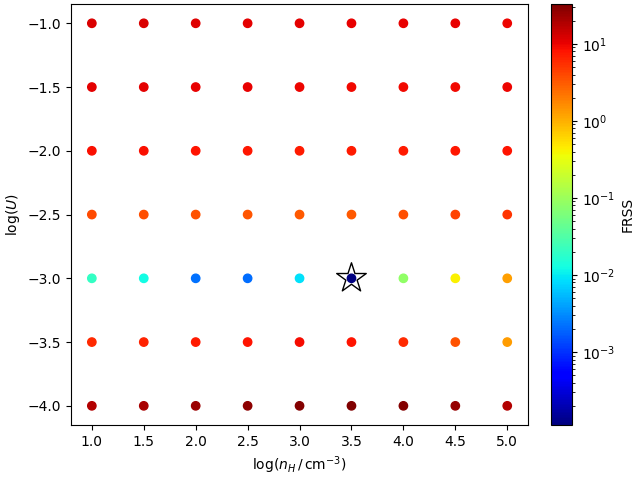

In [4]:
expected = np.array([0.438, 0.374, 0.068, 0.38, 12.9])
results = {k:sum((expected - v.iloc[-6:-1]['flux'].to_numpy())/expected)**2 for k, v in list(data_dict.items())}

hdens = np.array([i[0] for i in list(results.keys())])
us = np.array([i[1] for i in list(results.keys())])
results_list = np.array(list(results.values()))

norm = LogNorm(min(results_list), max(results_list))

fig, ax = plt.subplots(constrained_layout=True)
p = ax.scatter(hdens, us, c=results_list, cmap='jet', norm=norm)
ax.scatter(3.5, -3.0, s=500, marker='*', facecolors='none', edgecolor='black')
fig.colorbar(p, label='FRSS')
ax.set_xlabel('$\\log(n_H\\,/\\,\\mathrm{cm^{-3}})$')
ax.set_ylabel('$\\log(U)$')

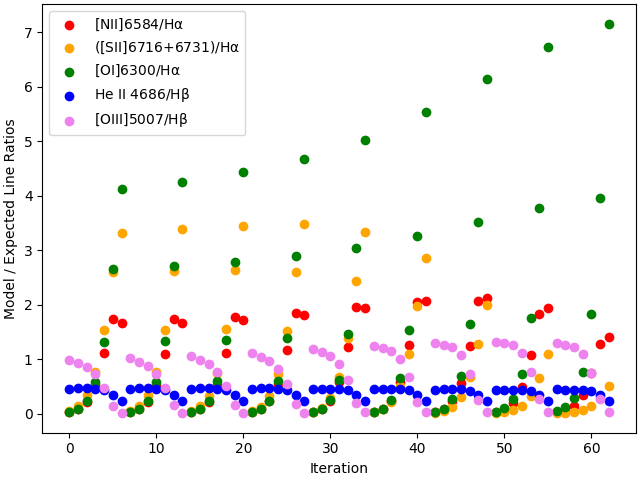

In [5]:
n2_has = [i.iloc[10]['flux'] for i in list(data_dict.values())] / expected[0]
s2_has = [i.iloc[11]['flux'] for i in list(data_dict.values())] / expected[1]
o1_has = [i.iloc[12]['flux'] for i in list(data_dict.values())] / expected[2]
he2_hbs = [i.iloc[13]['flux'] for i in list(data_dict.values())] / expected[3]
o3_hbs = [i.iloc[14]['flux'] for i in list(data_dict.values())] / expected[4]
fig, ax = plt.subplots(constrained_layout=True)
ax.scatter(range(len(n2_has)), n2_has, color='red', 
    label='[NII]6584/H$\\mathrm{\\alpha}$')
ax.scatter(range(len(s2_has)), s2_has, color='orange', 
    label='([SII]6716+6731)/H$\\mathrm{\\alpha}$')
ax.scatter(range(len(o1_has)), o1_has, color='green', 
    label='[OI]6300/H$\\mathrm{\\alpha}$')
ax.scatter(range(len(he2_hbs)), he2_hbs, color='blue', 
    label='He II 4686/H$\\mathrm{\\beta}$')
ax.scatter(range(len(o3_hbs)), o3_hbs, color='violet', 
    label='[OIII]5007/H$\\mathrm{\\beta}$')
ax.set_xlabel('Iteration')
ax.set_ylabel('Model / Expected Line Ratios')
ax.legend(loc='best')

In [15]:
min_idx = np.argmin(results_list)
min_coords = (hdens[min_idx], us[min_idx])
best_bdec = data_dict[min_coords].iloc[15]
print(f'Best-fit H-density: {min_coords[0]}')
print(f'Best-fit U: {min_coords[1]}')
print(f'Best-fit Balmer Decrement: {best_bdec['flux']}')
print(data_dict[min_coords])

Best-fit H-density: 3.5
Best-fit U: -3.0
Best-fit Balmer Decrement: 2.7906
               line      flux
0   he 2 4685.68A    0.161890
1   H  1 4861.32A    1.000000
2   o  3 4958.91A    3.023200
3   o  3 5006.84A    8.737800
4   blnd 6300.00A    0.291680
5   h  1 6562.80A    2.790600
6   n  2 6583.45A    1.538300
7   s  2 6716.44A    0.442670
8   Blnd 6720.00A    1.138000
9   s  2 6730.82A    0.695310
10            n2_ha  0.551243
11            s2_ha  0.407790
12            o1_ha  0.104522
13           he2_hb  0.161890
14            o3_hb  8.737800
15            ha_hb  2.790600


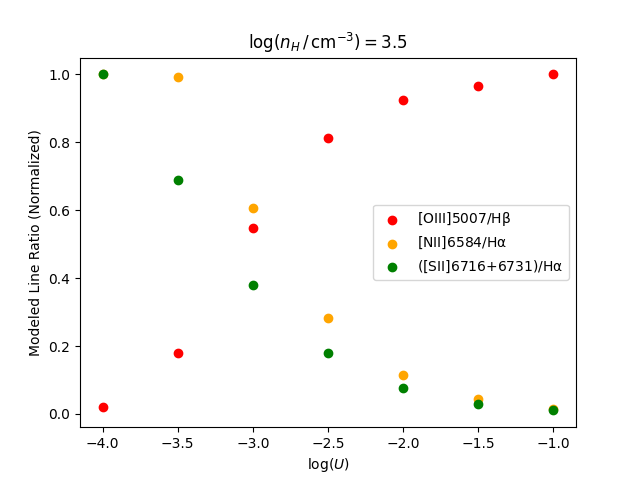

In [10]:
constant_continuum = [i for i in list(data_dict.keys()) if
    (i[0] == min_coords[0])]
o3_hb_cc = np.array([data_dict[i].iloc[14]['flux'] for i in constant_continuum])
n2_ha_cc = [data_dict[i].iloc[10]['flux'] for i in constant_continuum]
s2_ha_cc = [data_dict[i].iloc[11]['flux'] for i in constant_continuum]

fig, ax = plt.subplots()
ax.scatter([i[1] for i in constant_continuum], o3_hb_cc/max(o3_hb_cc), color='red',
    label='[OIII]5007/H$\\mathrm{\\beta}$')
ax.scatter([i[1] for i in constant_continuum], n2_ha_cc/max(n2_ha_cc), color='orange',
    label='[NII]6584/H$\\mathrm{\\alpha}$')
ax.scatter([i[1] for i in constant_continuum], s2_ha_cc/max(s2_ha_cc), color='green',
    label='([SII]6716+6731)/H$\\mathrm{\\alpha}$')

ax.set_ylabel('Modeled Line Ratio (Normalized)')
ax.set_xlabel('$\\log(U)$')

ax.set_title(f'$\\log(n_H \\,/\\, \\mathrm{{cm^{{-3}}}})={min_coords[0]}$')

ax.legend(loc='best')

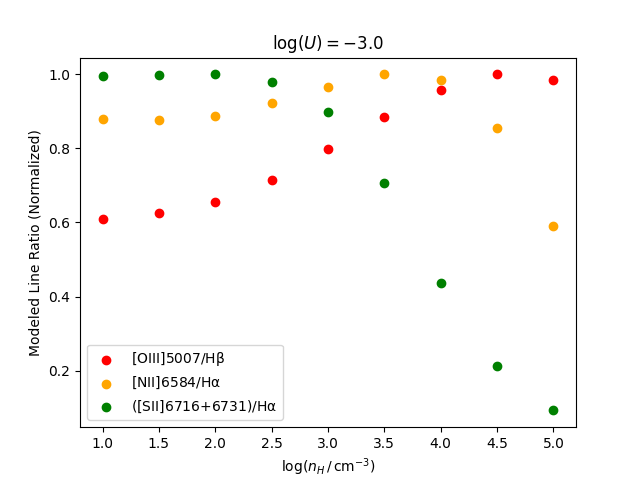

In [14]:
const_U = [i for i in list(data_dict.keys()) if
    (i[1] == min_coords[1])]
o3_hb_cc = np.array([data_dict[i].iloc[14]['flux'] for i in constant_continuum])
n2_ha_cc = [data_dict[i].iloc[10]['flux'] for i in constant_continuum]
s2_ha_cc = [data_dict[i].iloc[11]['flux'] for i in constant_continuum]

fig, ax = plt.subplots()
ax.scatter([i[0] for i in constant_continuum], o3_hb_cc/max(o3_hb_cc), color='red',
    label='[OIII]5007/H$\\mathrm{\\beta}$')
ax.scatter([i[0] for i in constant_continuum], n2_ha_cc/max(n2_ha_cc), color='orange',
    label='[NII]6584/H$\\mathrm{\\alpha}$')
ax.scatter([i[0] for i in constant_continuum], s2_ha_cc/max(s2_ha_cc), color='green',
    label='([SII]6716+6731)/H$\\mathrm{\\alpha}$')

ax.set_ylabel('Modeled Line Ratio (Normalized)')
ax.set_xlabel(f'$\\log(n_H \\,/\\, \\mathrm{{cm^{{-3}}}})$')

ax.set_title(f'$\\log(U)={min_coords[1]}$')

ax.legend(loc='best')